### Importation des bibliothèques

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,make_scorer, recall_score,f1_score
from xgboost import XGBClassifier
import joblib

In [13]:
data=pd.read_csv("../data/data_preprocessed.csv")

In [14]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,no_assessment_taken,low_performance,grade2_echec,Marital_status_grouped,Application_mode_grouped,Mother's_qualification_grouped,Father's_qualification_grouped,Mother's_occupation_grouped,Father's_occupation_grouped,Previous_qualification_grouped
0,1,17,5,Animation et conception multimédia,journée,1,122.0,1,19,12,...,0,0,0,Single,2e phase - contingent général,Éducation de base,Enseignement secondaire,Services / vente / sécurité,Travailleurs non qualifiés,Enseignement secondaire
1,1,15,1,Tourisme,journée,1,160.0,1,1,3,...,0,0,0,Single,Other,Enseignement secondaire,Enseignement supérieur,Techniciens / professions intermédiaires,Techniciens / professions intermédiaires,Enseignement secondaire
2,1,1,5,Design de communication,journée,1,122.0,1,37,37,...,1,0,0,Single,1ère phase - contingent général,Éducation de base,Éducation de base,Travailleurs non qualifiés,Travailleurs non qualifiés,Enseignement secondaire
3,1,17,2,Journalisme et communication,journée,1,122.0,1,38,37,...,0,0,0,Single,2e phase - contingent général,Éducation de base,Éducation de base,Services / vente / sécurité,Techniciens / professions intermédiaires,Enseignement secondaire
4,2,39,1,Service social (présence en soirée),soirée,1,100.0,1,37,38,...,0,0,0,Married,Plus de 23 ans,Éducation de base,Éducation de base,Travailleurs non qualifiés,Travailleurs non qualifiés,Enseignement secondaire


In [15]:
data1=data.drop(columns=["Marital status","Application mode","Previous qualification","Nacionality","Mother's qualification","Father's qualification",
"Mother's occupation","Father's occupation"])

In [16]:
data1.columns

Index(['Application order', 'Course', 'Daytime/evening attendance',
       'Previous qualification (grade)', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target', 'no_academic_activity',
       'no_assessment_taken', 'low_performance',

In [17]:
infos=data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 40 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Application order                               3630 non-null   int64  
 1   Course                                          3630 non-null   object 
 2   Daytime/evening attendance                      3630 non-null   object 
 3   Previous qualification (grade)                  3630 non-null   float64
 4   Admission grade                                 3630 non-null   float64
 5   Displaced                                       3630 non-null   object 
 6   Educational special needs                       3630 non-null   object 
 7   Debtor                                          3630 non-null   object 
 8   Tuition fees up to date                         3630 non-null   object 
 9   Gender                                   

In [18]:
X=data1.drop(columns="Target")
Y=data1["Target"]



num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns


print(num_cols)
print(cat_cols)

Index(['Application order', 'Previous qualification (grade)',
       'Admission grade', 'Age at enrollment',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'no_academic_activity', 'no_assessment_taken',
       'low_performance', 'grade2_echec'],
      dtype='object')
Index(['Course', 'Daytime/evening attendance', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'S

In [19]:
def separe(data,liste):


    data1=data.drop(columns=liste)

    X=data1.drop(columns='Target')
    Y=data1["Target"]
    

    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(include=['object', 'category']).columns

    preprocessor=ColumnTransformer([
        ("num",StandardScaler(),num_cols),
        ("cat",OneHotEncoder(),cat_cols)
    ])

    x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

    return preprocessor,x_train,x_test,y_train,y_test

In [20]:
def weighted_f1(y_true, y_pred):
    f1_dropout = f1_score(y_true, y_pred, labels=[1], average="macro")
    f1_graduate = f1_score(y_true, y_pred, labels=[2], average="macro")
    f1_enrolled = f1_score(y_true, y_pred, labels=[3], average="macro")

    return 0.6*f1_dropout + 0.3*f1_graduate + 0.1*f1_enrolled

scorer = make_scorer(weighted_f1)

In [21]:
def train_search(model,preprocessor,x_train,y_train,param):
    pip=Pipeline(steps=[
        ("preprocessor",preprocessor),
        ("classifier",model)
    ])    
    grid=GridSearchCV(
        estimator=pip,
        cv=5,
        param_grid=param,
        scoring="recall"
    )
    grid.fit(x_train,y_train)
    return grid.best_estimator_

    
    

In [22]:
def resultats(x_train,y_train,x_test,y_test,pipeline):
    print(f"accuracy_train={accuracy_score(y_train,pipeline.predict(x_train))}")
    print(f"accuracy_test={accuracy_score(y_test,pipeline.predict(x_test))}")

    y_pred=pipeline.predict(x_test)
    print(classification_report(y_test,y_pred))
    
    confusion=confusion_matrix(y_test,y_pred)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax1
)
    ax1.set_title("Matrice de confusion")

    ax2.hist(pipeline.predict_proba(x_test)[:,0])
    ax2.set_title("histogramme des probabilités")

In [23]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"]
}

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.9025482093663911
accuracy_test=0.9256198347107438
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       442
           1       0.95      0.86      0.90       284

    accuracy                           0.93       726
   macro avg       0.93      0.91      0.92       726
weighted avg       0.93      0.93      0.92       726



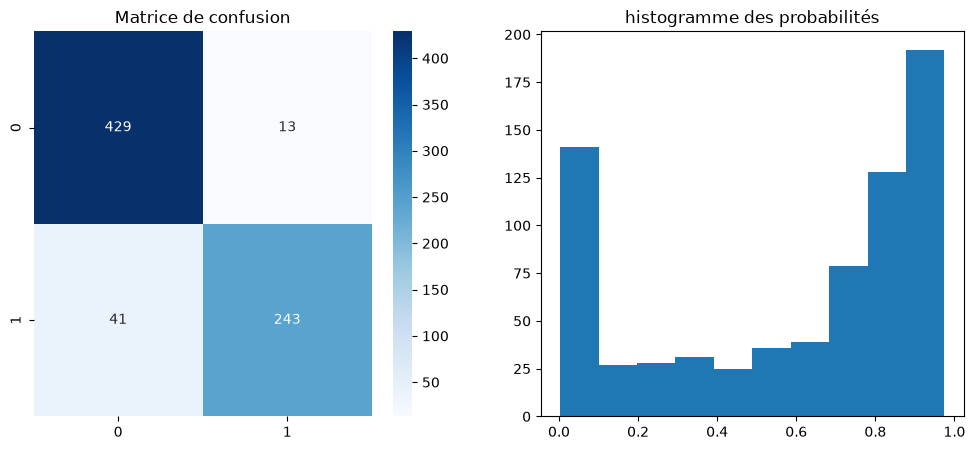

In [24]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,[])

model1=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model1)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.9049586776859504
accuracy_test=0.9269972451790633
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       442
           1       0.90      0.92      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



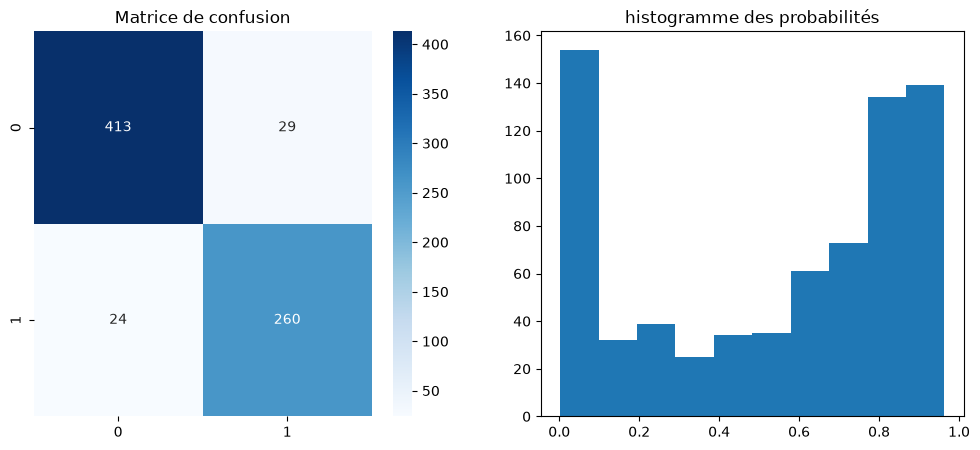

In [25]:

model2=train_search(LogisticRegression(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model2)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.8977272727272727
accuracy_test=0.9146005509641874
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       442
           1       0.92      0.86      0.89       284

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726



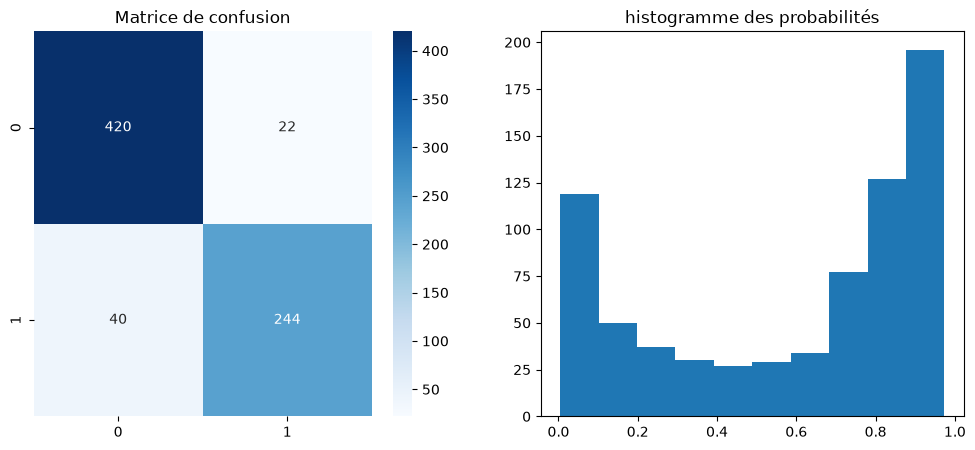

In [26]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken','low_performance','grade2_echec'])

model3=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model3)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.9011707988980716
accuracy_test=0.9214876033057852
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       442
           1       0.89      0.92      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



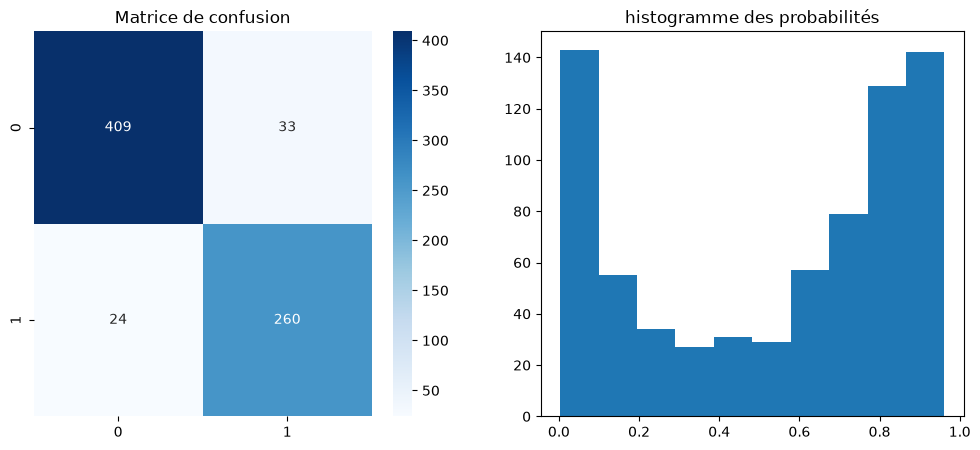

In [27]:
model4=train_search(LogisticRegression(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model4)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.897038567493113
accuracy_test=0.9159779614325069
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       442
           1       0.93      0.85      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726



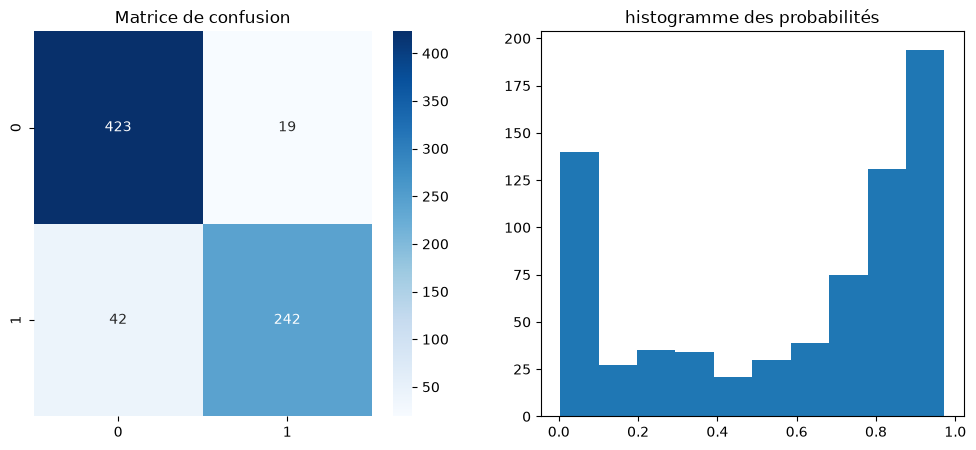

In [28]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity'])

model5=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model5)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.9011707988980716
accuracy_test=0.9201101928374655
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       442
           1       0.89      0.91      0.90       284

    accuracy                           0.92       726
   macro avg       0.91      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



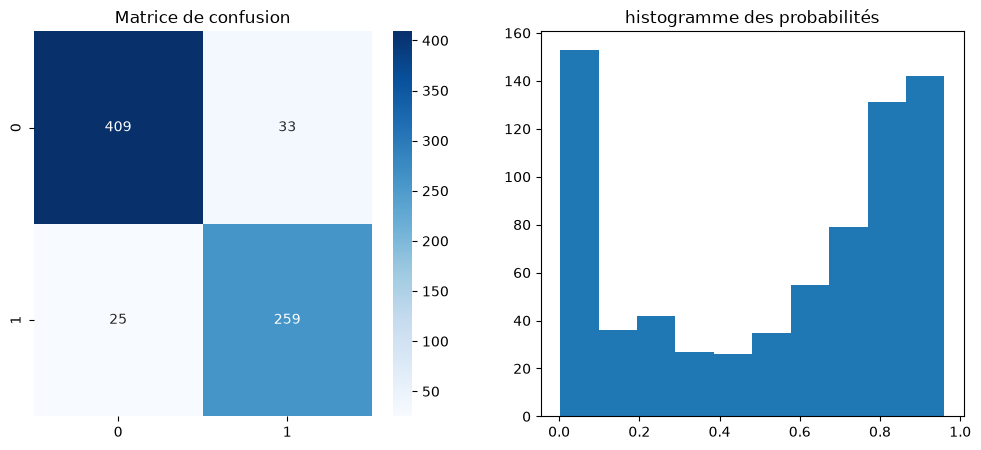

In [29]:
model6=train_search(LogisticRegression(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model6)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.8973829201101928
accuracy_test=0.9146005509641874
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       442
           1       0.92      0.86      0.89       284

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726



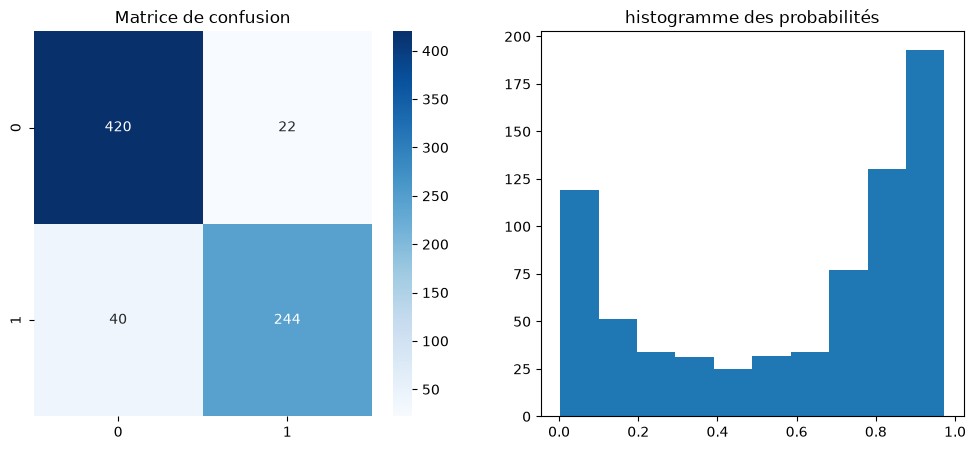

In [30]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken','grade2_echec'])

model7=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model7)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.8987603305785123
accuracy_test=0.9159779614325069
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       442
           1       0.92      0.86      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



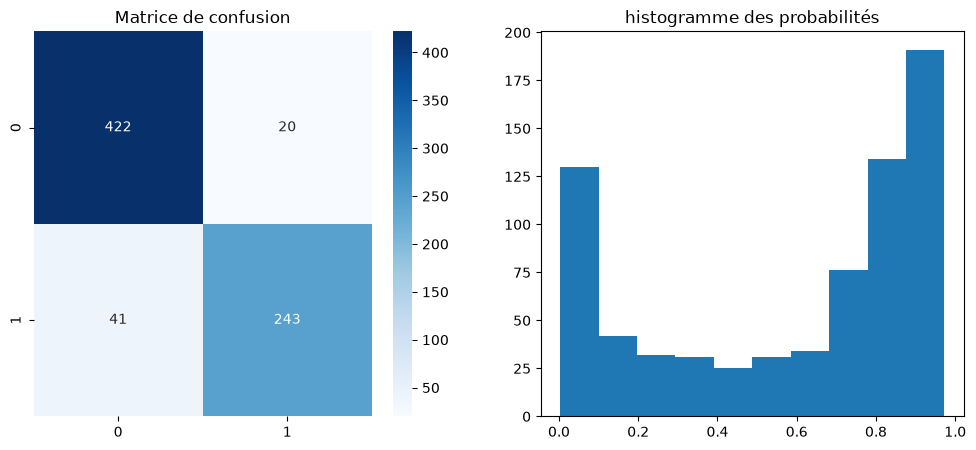

In [31]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken'])
model8=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model8)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.8984159779614325
accuracy_test=0.9118457300275482
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       442
           1       0.92      0.85      0.88       284

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726



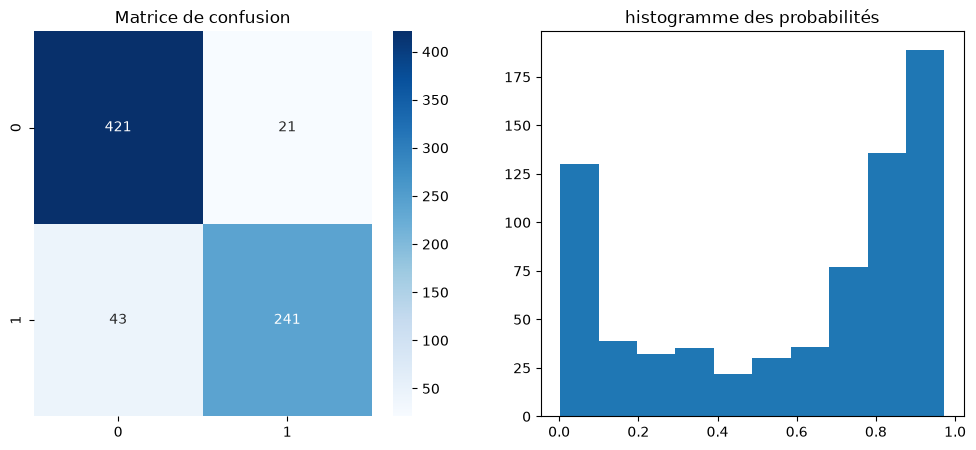

In [32]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken','Curricular units 1st sem (credited)','Curricular units 2nd sem (credited)'])
model9=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model9)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.8973829201101928
accuracy_test=0.9159779614325069
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       442
           1       0.92      0.86      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



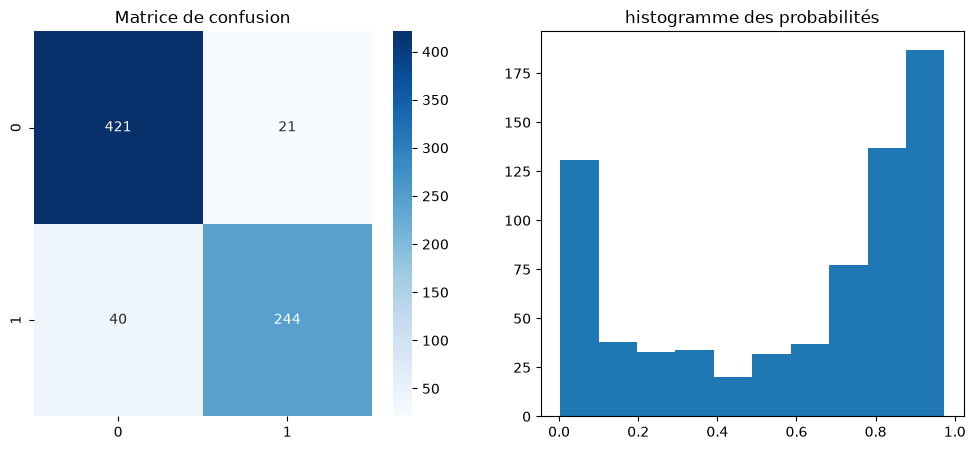

In [33]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken','Curricular units 1st sem (credited)','Curricular units 2nd sem (credited)','Curricular units 1st sem (without evaluations)','Curricular units 2nd sem (without evaluations)'])
model10=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model10)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
 

accuracy_train=0.9025482093663911
accuracy_test=0.9256198347107438
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       442
           1       0.95      0.86      0.90       284

    accuracy                           0.93       726
   macro avg       0.93      0.91      0.92       726
weighted avg       0.93      0.93      0.92       726



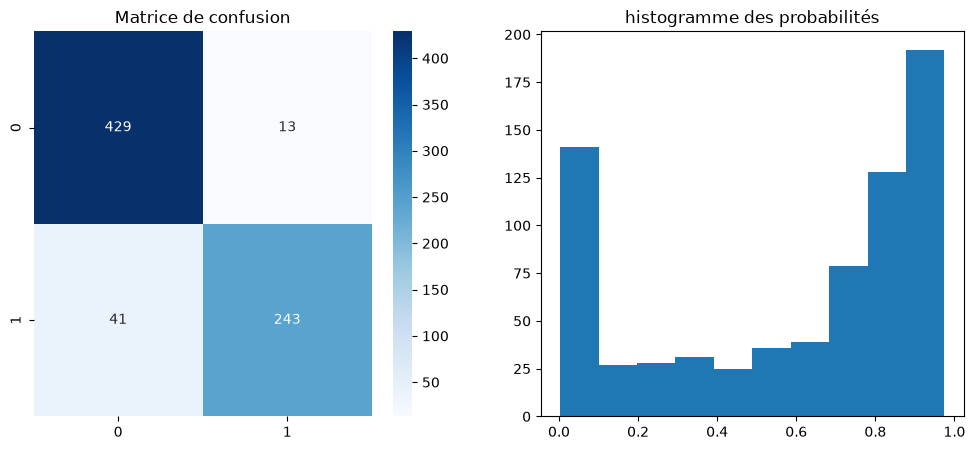

In [34]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,[])

model1=train_search(LogisticRegression(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,model1)

In [35]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,[])

In [36]:
param_grid= {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10,20]
}

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9493801652892562
accuracy_test=0.9242424242424242
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.94      0.86      0.90       284

    accuracy                           0.92       726
   macro avg       0.93      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



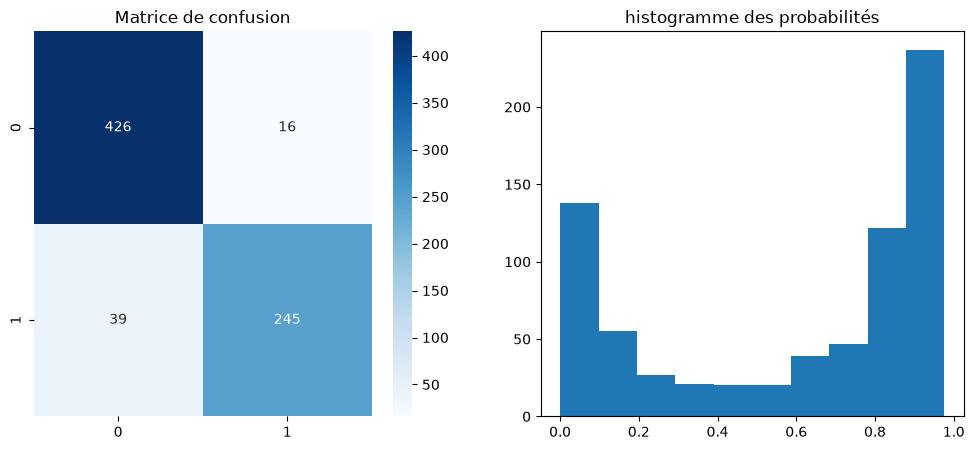

In [37]:
foret1=train_search(RandomForestClassifier(),preprocessor,x_train,y_train,param_grid)
resultats(x_train,y_train,x_test,y_test,foret1)

In [38]:
foret1.named_steps["classifier"].feature_importances_

array([1.24276157e-03, 1.01564409e-02, 4.28507162e-03, 2.42549000e-03,
       1.35326842e-02, 7.42695062e-04, 5.18875753e-03, 6.09330945e-03,
       5.70258592e-03, 6.73008133e-03, 1.38304143e-02, 2.17577035e-02,
       3.78108662e-03, 1.66715294e-02, 1.92223624e-02, 1.24296418e-01,
       5.54924011e-02, 2.75855985e-03, 3.01088290e-03, 1.18186188e-02,
       3.16502652e-02, 1.87974576e-01, 1.33249374e-01, 2.40967682e-03,
       7.31575669e-03, 6.53080012e-03, 7.55446221e-03, 3.74906191e-03,
       1.11180565e-02, 1.54863811e-02, 1.00713850e-02, 1.93524178e-04,
       5.09952673e-03, 8.46610437e-04, 9.38035585e-04, 1.14605841e-03,
       8.51494624e-04, 2.44305034e-03, 2.81208620e-04, 9.65744797e-04,
       2.61085287e-03, 1.00600797e-03, 2.91194617e-03, 1.23283822e-03,
       1.97489197e-05, 9.71539370e-04, 3.75066417e-03, 1.00757742e-03,
       1.12658947e-03, 9.25311512e-04, 2.67081399e-03, 1.76105029e-03,
       3.02645042e-04, 1.75960886e-04, 1.11147503e-02, 1.13698862e-02,
      

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9555785123966942
accuracy_test=0.9256198347107438
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       442
           1       0.91      0.89      0.90       284

    accuracy                           0.93       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



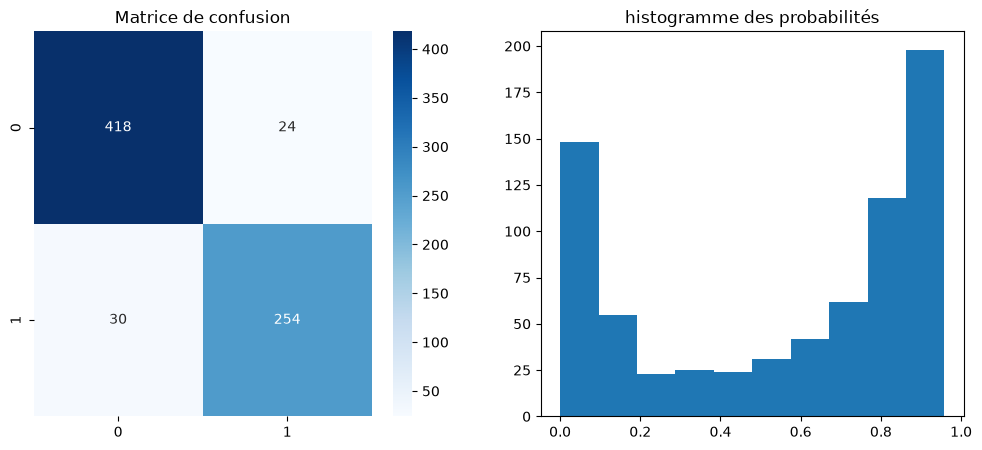

In [39]:
foret1=train_search(RandomForestClassifier(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)
resultats(x_train,y_train,x_test,y_test,foret1)

In [40]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken','low_performance','grade2_echec'])

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9500688705234159
accuracy_test=0.9214876033057852
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       442
           1       0.93      0.86      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



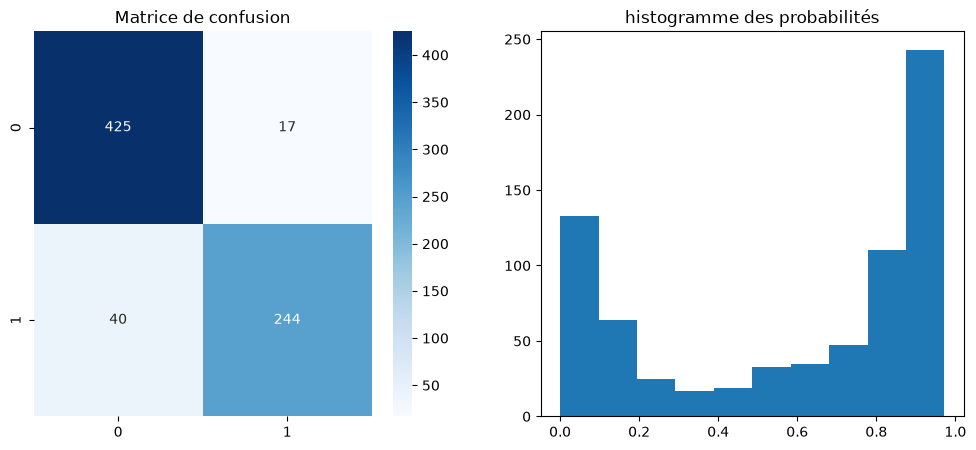

In [41]:
foret2=train_search(RandomForestClassifier(),preprocessor,x_train,y_train,param_grid)
resultats(x_train,y_train,x_test,y_test,foret2)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.959366391184573
accuracy_test=0.9214876033057852
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       442
           1       0.90      0.89      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



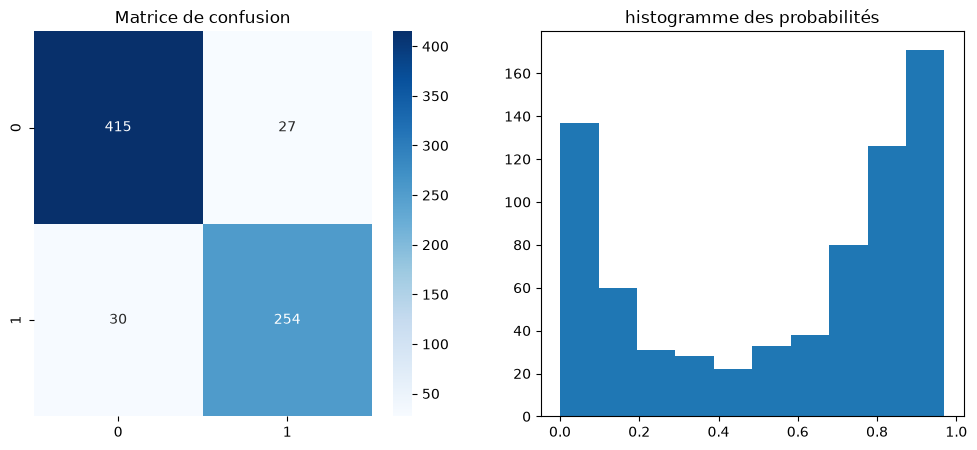

In [42]:
foret3=train_search(RandomForestClassifier(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)
resultats(x_train,y_train,x_test,y_test,foret3)

In [43]:
import pandas as pd

feature_names = foret1.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": foret1.named_steps["classifier"].feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df.head(20))

                                         Feature  Importance
21      num__Curricular units 2nd sem (approved)    0.206225
22         num__Curricular units 2nd sem (grade)    0.125120
15      num__Curricular units 1st sem (approved)    0.101346
16         num__Curricular units 1st sem (grade)    0.067395
57              cat__Tuition fees up to date_oui    0.047689
56              cat__Tuition fees up to date_non    0.034835
20   num__Curricular units 2nd sem (evaluations)    0.028403
29                          num__low_performance    0.025659
14   num__Curricular units 1st sem (evaluations)    0.024462
11                        num__Age at enrollment    0.021744
61                   cat__Scholarship holder_oui    0.018993
54                               cat__Debtor_non    0.017286
30                             num__grade2_echec    0.014567
13      num__Curricular units 1st sem (enrolled)    0.013883
10                          num__Admission grade    0.013510
60                   cat

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.943870523415978
accuracy_test=0.9214876033057852
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.93      0.86      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



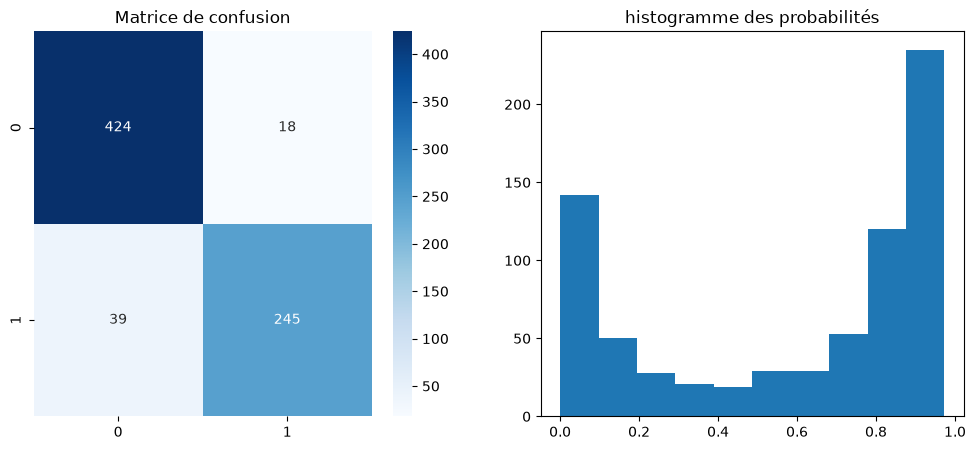

In [44]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity'])

foret4=train_search(RandomForestClassifier(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,foret4)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9473140495867769
accuracy_test=0.9228650137741047
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       442
           1       0.93      0.87      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



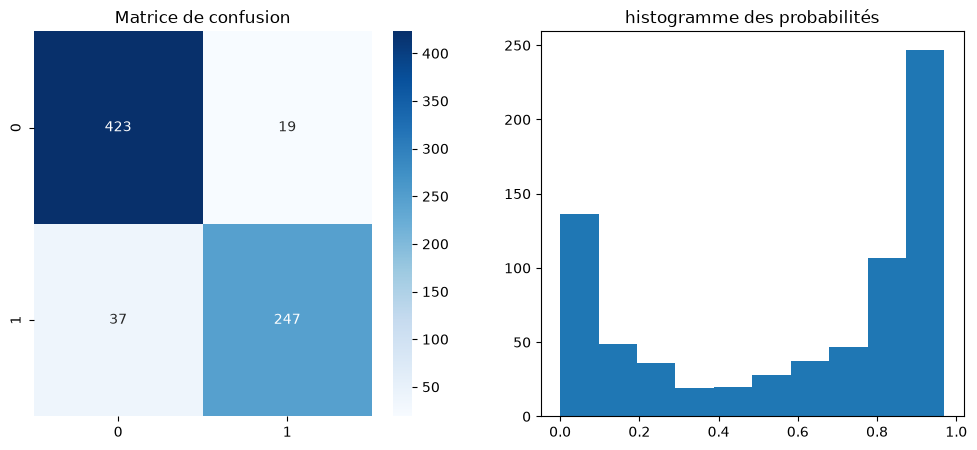

In [48]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken','grade2_echec'])

foret5=train_search(RandomForestClassifier(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,foret5)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9559228650137741
accuracy_test=0.9214876033057852
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       442
           1       0.90      0.90      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



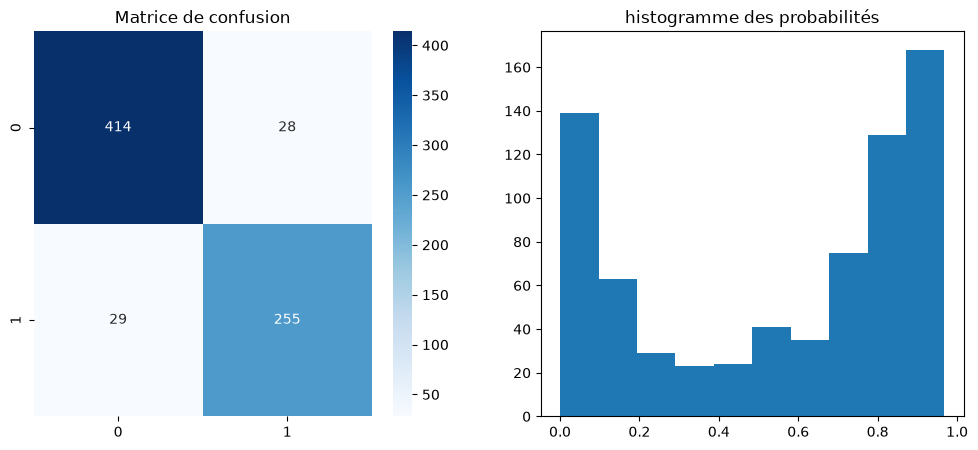

In [49]:
foret5=train_search(RandomForestClassifier(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,foret5)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9476584022038568
accuracy_test=0.918732782369146
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       442
           1       0.92      0.86      0.89       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



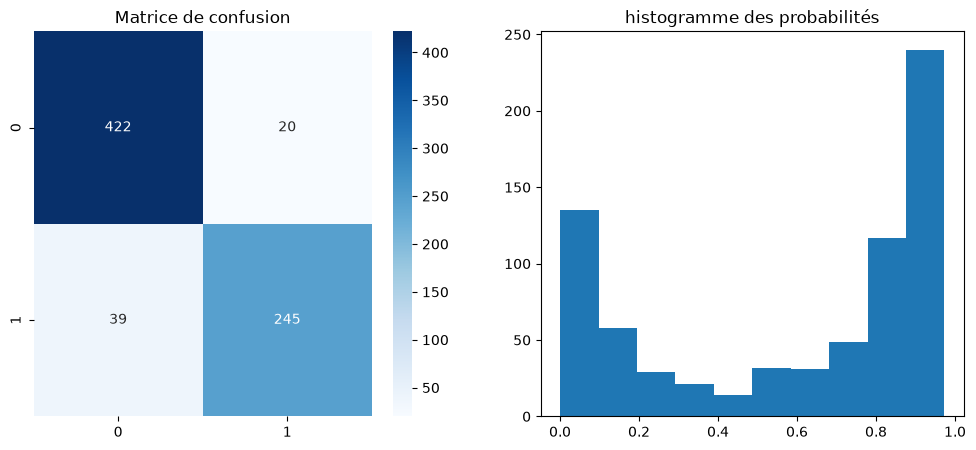

In [50]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken'])
foret5=train_search(RandomForestClassifier(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,foret5)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9559228650137741
accuracy_test=0.9201101928374655
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       442
           1       0.90      0.90      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



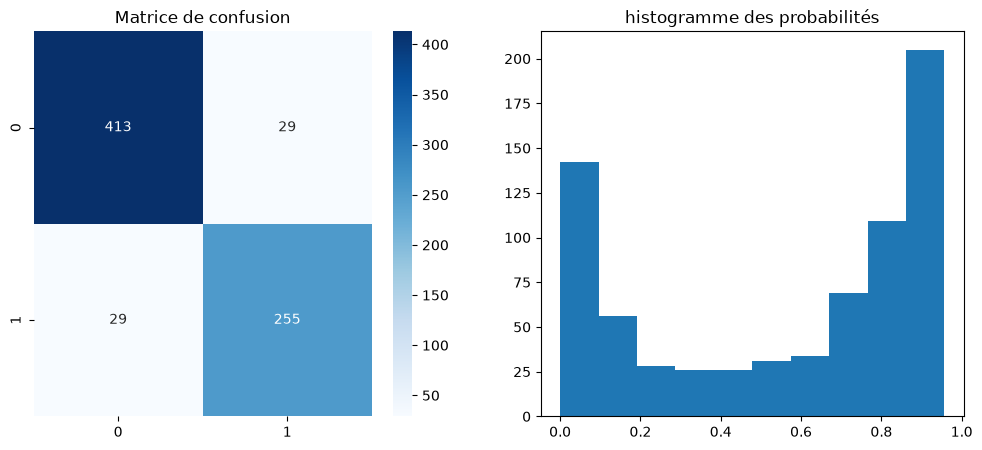

In [51]:
preprocessor,x_train,x_test,y_train,y_test=separe(data,['no_academic_activity','no_assessment_taken'])
foret5=train_search(RandomForestClassifier(class_weight="balanced"),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,foret5)

c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dropout prediction\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...

accuracy_train=0.9380165289256198
accuracy_test=0.8980716253443526
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       442
           1       0.90      0.83      0.86       284

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



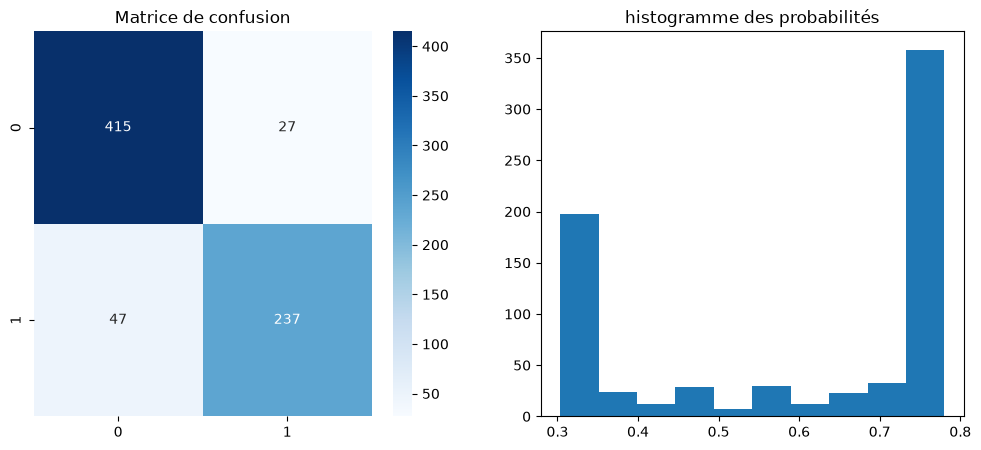

In [57]:
param_grid= {
    "classifier__n_estimators": [2],
    "classifier__max_depth": [10,5]
}

preprocessor,x_train,x_test,y_train,y_test=separe(data,[])
foret5=train_search(XGBClassifier(),preprocessor,x_train,y_train,param_grid)

resultats(x_train,y_train,x_test,y_test,foret5)

In [62]:
joblib.dump(model2, "../models/pipeline_dropout.pkl")

['../models/pipeline_dropout.pkl']